# 06 — Detection Validation

Establishes whether flagged pixels are methane or a surface confound, using a
scene with a **known** answer as the control.

### Why this notebook exists

A matched filter thresholded at mean + N sigma **always** returns pixels — a
continuous score distribution always has a tail. There is no "nothing here"
outcome. So detection alone is not evidence; the flagged pixels have to be
validated against something independent.

### The control scene

`20241121_183741_33_4001` (Casa Grande, Pinal County, AZ) carries the STAC note
*"Controlled release plume example. Plume A is a controlled release."* — a metered
methane release at a known location. Any method that cannot find it is broken,
regardless of what it reports elsewhere.

### Sections
1. Baseline: scene-wide matched filter on both scenes
2. STAC metadata for the control scene
3. Where the top-scoring pixels actually are
4. Column-wise matched filter (push-broom striping fix)
5. Side-by-side comparison
6. Isolate the plume and run the shape test on it alone

In [16]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import label

from tanager_diagnostics import (
    run_validation, plot_validation,
    load_scene, swir_matrix, hitran_ch4_k,
    brightness_matched_ratio, hitran_shape_test,
    BAND_LO, BAND_HI,
)

SCENE_AZ = "../data/raw/20241121_183741_33_4001_basic_radiance.h5"
SCENE_TX = "../data/raw/20250205_175845_00_4001_basic_radiance.h5"
FIGDIR   = Path("../outputs/figures")
CACHE    = Path("../data/processed")
FIGDIR.mkdir(parents=True, exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

for p in (SCENE_AZ, SCENE_TX):
    print(f"{'OK ' if Path(p).exists() else 'MISSING'}  {p}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
OK   ../data/raw/20241121_183741_33_4001_basic_radiance.h5
OK   ../data/raw/20250205_175845_00_4001_basic_radiance.h5


## 1. Baseline — scene-wide matched filter

This is the method as originally built: one background mean and covariance for the
whole scene. Run on both the control (AZ, known plume) and the study scene (TX).

Takes several minutes per scene.

Using ../data/reference/hitran

CH4
                     Lines parsed: 50571
{'air': 1.0}
12.860513 seconds elapsed for abscoef; nlines = 50571
VALIDATION — 20241121_183741_33_4001_basic_radiance
  Flagged pixels           : 212
  MF threshold             : 0.0622

  Brightness-matched control
    ratio outside CH4 bands: 0.988   (want ~1.00)
    ratio inside  CH4 bands: 0.948
    differential           : 0.0398

  HITRAN shape test
    correlation            : 0.748
    observed peak          : 2350 nm
    HITRAN peak            : 2370 nm
    offset                 : 20 nm   (want <15)

  VERDICT: REJECT - absorption feature does not match CH4; check surface mineralogy (calcite ~2340 nm is common in caliche soils)
Saved: ../outputs/figures/validation_arizona.png


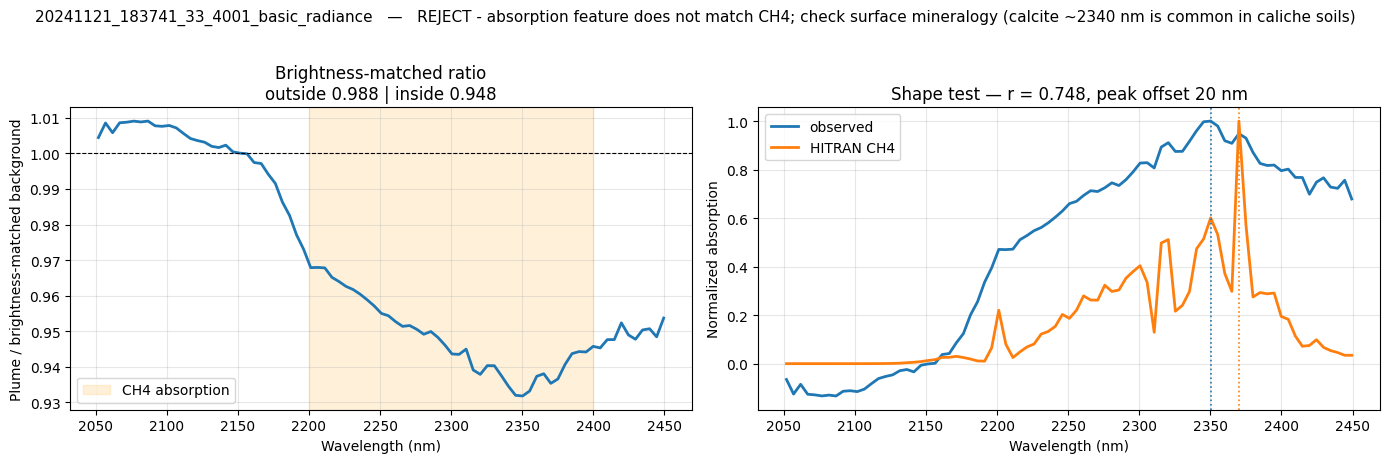

In [17]:
arizona = run_validation(SCENE_AZ)
plot_validation(arizona, FIGDIR / "validation_arizona.png")

Using ../data/reference/hitran

CH4
                     Lines parsed: 50571
{'air': 1.0}
12.904978 seconds elapsed for abscoef; nlines = 50571
VALIDATION — 20250205_175845_00_4001_basic_radiance
  Flagged pixels           : 106
  MF threshold             : 0.0785

  Brightness-matched control
    ratio outside CH4 bands: 0.996   (want ~1.00)
    ratio inside  CH4 bands: 0.964
    differential           : 0.0320

  HITRAN shape test
    correlation            : 0.715
    observed peak          : 2340 nm
    HITRAN peak            : 2370 nm
    offset                 : 30 nm   (want <15)

  VERDICT: REJECT - absorption feature does not match CH4; check surface mineralogy (calcite ~2340 nm is common in caliche soils)
Saved: ../outputs/figures/validation_permian.png


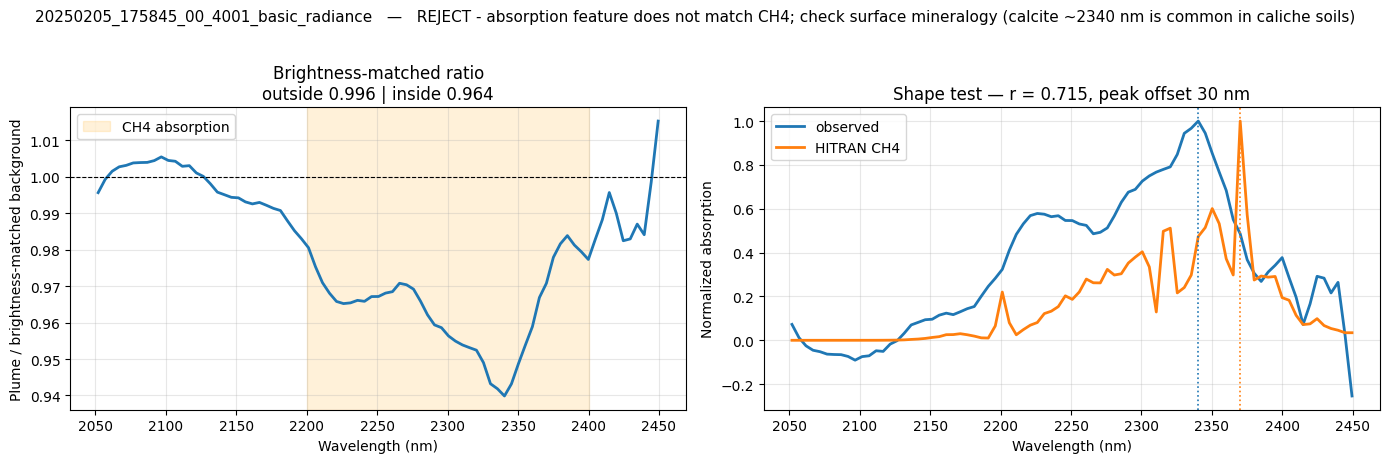

In [18]:
permian = run_validation(SCENE_TX)
plot_validation(permian, FIGDIR / "validation_permian.png")

**Read the two together.** If both scenes return near-identical curves — same peak
position, same correlation, same smooth featureless bowl — despite being different
states, land cover and seasons, that similarity is a property of the *method*, not
of either landscape.

## 2. STAC metadata for the control scene

In [19]:
import pystac

item = pystac.Item.from_file(
    "https://www.planet.com/data/stac/tanager-core-imagery/GHG-plumes/"
    "20241121_183741_33_4001/20241121_183741_33_4001.json"
)

for key in ("location_description", "notes", "plume_provider_ids",
            "gsd", "view:off_nadir", "view:sun_elevation", "light_haze_percent"):
    print(f"{key:24s}: {item.properties.get(key)}")

location_description    : Casa Grande, Pinal County, Arizona, United States
notes                   : Controlled release plume example. Plume A is a conrolled release.
plume_provider_ids      : ['tan20241121t183727c00s4001-A']
gsd                     : 43.56
view:off_nadir          : 29.9
view:sun_elevation      : 36.4
light_haze_percent      : 66


Two things to carry forward:

- `notes` confirms a **controlled release** — ground truth exists for this scene.
- `gsd` is ~43.6 m, not the 30 m nadir spec, because `view:off_nadir` is ~30 degrees.
  Any pixel-area or emission-rate calculation must use the actual GSD.

## 3. Where are the top-scoring pixels?

A plume is compact and elongated along the wind. Surface mineralogy is scattered
blobs. Sensor striping is vertical lines spanning the full frame. Tightening the
threshold well past 2 sigma shows which of the three dominates.

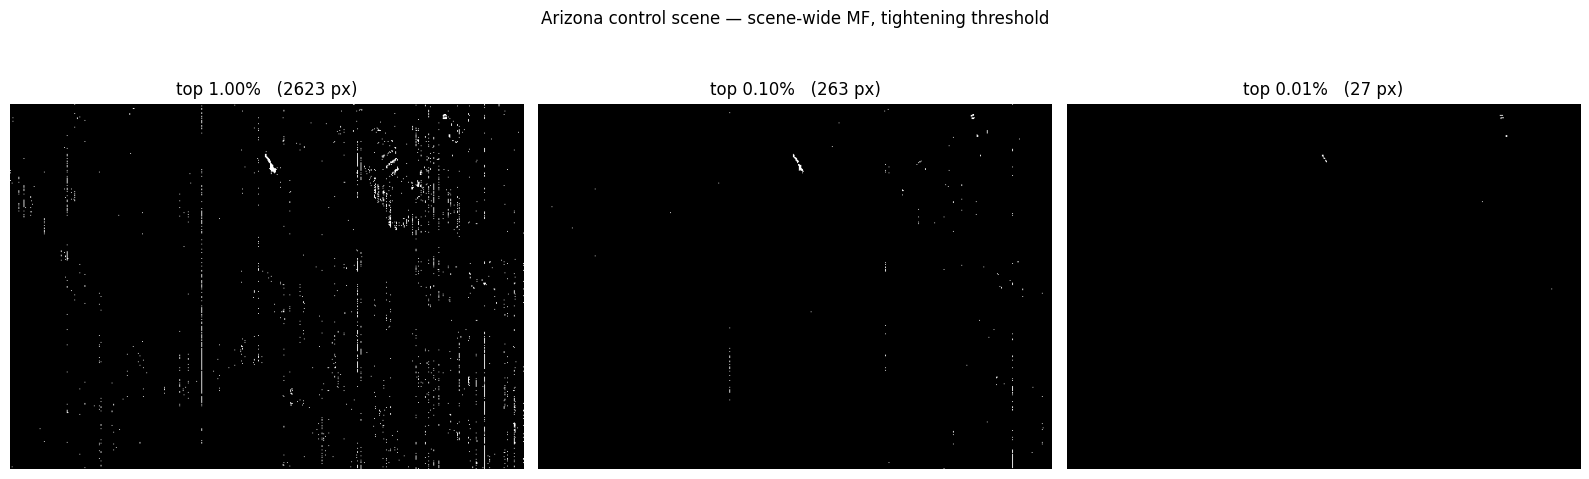

In [20]:
mf_scene = arizona.arrays["mf_map"]

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
for a, pct in zip(ax, [99.0, 99.9, 99.99]):
    m = mf_scene > np.nanpercentile(mf_scene, pct)
    a.imshow(m, cmap="gray")
    a.set_title(f"top {100 - pct:.2f}%   ({int(m.sum())} px)")
    a.axis("off")
fig.suptitle("Arizona control scene — scene-wide MF, tightening threshold", y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR / "az_threshold_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Column-wise matched filter

Tanager is a push-broom sensor: each cross-track sample is read out by its own
detector column with its own gain and dark offset. A scene-wide covariance treats
that fixed-pattern structure as signal, which is why the threshold sweep above is
dominated by vertical stripes.

Estimating background statistics **per column** removes it. This is standard for
AVIRIS, EMIT and PRISMA matched filters.

Shrinkage is applied to the covariance because each column has only ~432 lines to
estimate an 81x81 matrix — too few for a stable sample covariance.

In [21]:
def matched_filter_columnwise(rad, wl, k, wl_min=2050, wl_max=2450, shrink=0.15):
    """
    Per-detector-column matched filter.

    Parameters
    ----------
    rad : (bands, lines, samples) radiance cube, NaN for fill
    wl  : (bands,) wavelengths in nm
    k   : (n_swir,) CH4 absorption coefficient spectrum on the SWIR band centers.
          Must match the number of bands the wl_min/wl_max window selects —
          derive it with swir_matrix() rather than assuming a count.

    Returns
    -------
    mf   : (lines, samples) matched filter score, NaN where invalid
    wl_s : (n_swir,) wavelengths actually used
    """
    sel  = (wl >= wl_min) & (wl <= wl_max)
    wl_s = wl[sel]
    cube = rad[sel]
    nb, nl, ns = cube.shape

    if len(k) != nb:
        raise ValueError(
            f"k has {len(k)} bands but the SWIR window selects {nb}. "
            "Build k from swir_matrix(rad, wl)[1]."
        )

    mf = np.full((nl, ns), np.nan)

    for j in range(ns):
        Xc = cube[:, :, j].T                      # (lines, bands)
        ok = ~np.any(np.isnan(Xc), axis=1)
        if ok.sum() < nb + 10:
            continue

        Xv = Xc[ok]
        mu = Xv.mean(axis=0)
        S  = np.cov((Xv - mu).T)
        S  = (1 - shrink) * S + shrink * np.trace(S) / nb * np.eye(nb)

        try:
            Si = np.linalg.inv(S)
        except np.linalg.LinAlgError:
            continue

        t  = -k * mu                              # negative: methane absorbs
        t /= np.linalg.norm(t) + 1e-12
        Si_t = Si @ t
        mf[ok, j] = ((Xv - mu) @ Si_t) / (t @ Si_t + 1e-12)

    return mf, wl_s


print("defined")

defined


In [22]:
# Load the control scene and build the target on its ACTUAL band centers.
rad_az, wl_az, lat_az, lon_az = load_scene(SCENE_AZ)
X_az, wl_swir_az, valid_az, shape_az = swir_matrix(rad_az, wl_az)

k_az = hitran_ch4_k(wl_swir_az)
if k_az is None:
    raise RuntimeError("hapi unavailable — run: pip install hitran-api")

print(f"SWIR bands: {len(wl_swir_az)}   k length: {len(k_az)}   (must match)")

Using ../data/reference/hitran

CH4
                     Lines parsed: 50571
{'air': 1.0}
12.741507 seconds elapsed for abscoef; nlines = 50571
SWIR bands: 81   k length: 81   (must match)


In [23]:
# Slow: inverts one covariance per detector column (~607 of them).
# Cached so downstream cells can be re-run freely.
MF_COL_PATH = CACHE / "mf_columnwise_20241121.npy"

if MF_COL_PATH.exists():
    mf_col = np.load(MF_COL_PATH)
    print(f"loaded cache: {MF_COL_PATH}")
else:
    mf_col, _ = matched_filter_columnwise(rad_az, wl_az, k_az)
    np.save(MF_COL_PATH, mf_col)
    print(f"computed and cached: {MF_COL_PATH}")

print(f"shape {mf_col.shape} | valid {np.isfinite(mf_col).sum():,} px")

loaded cache: ../data/processed/mf_columnwise_20241121.npy
shape (432, 607) | valid 262,224 px


## 5. Scene-wide vs column-wise

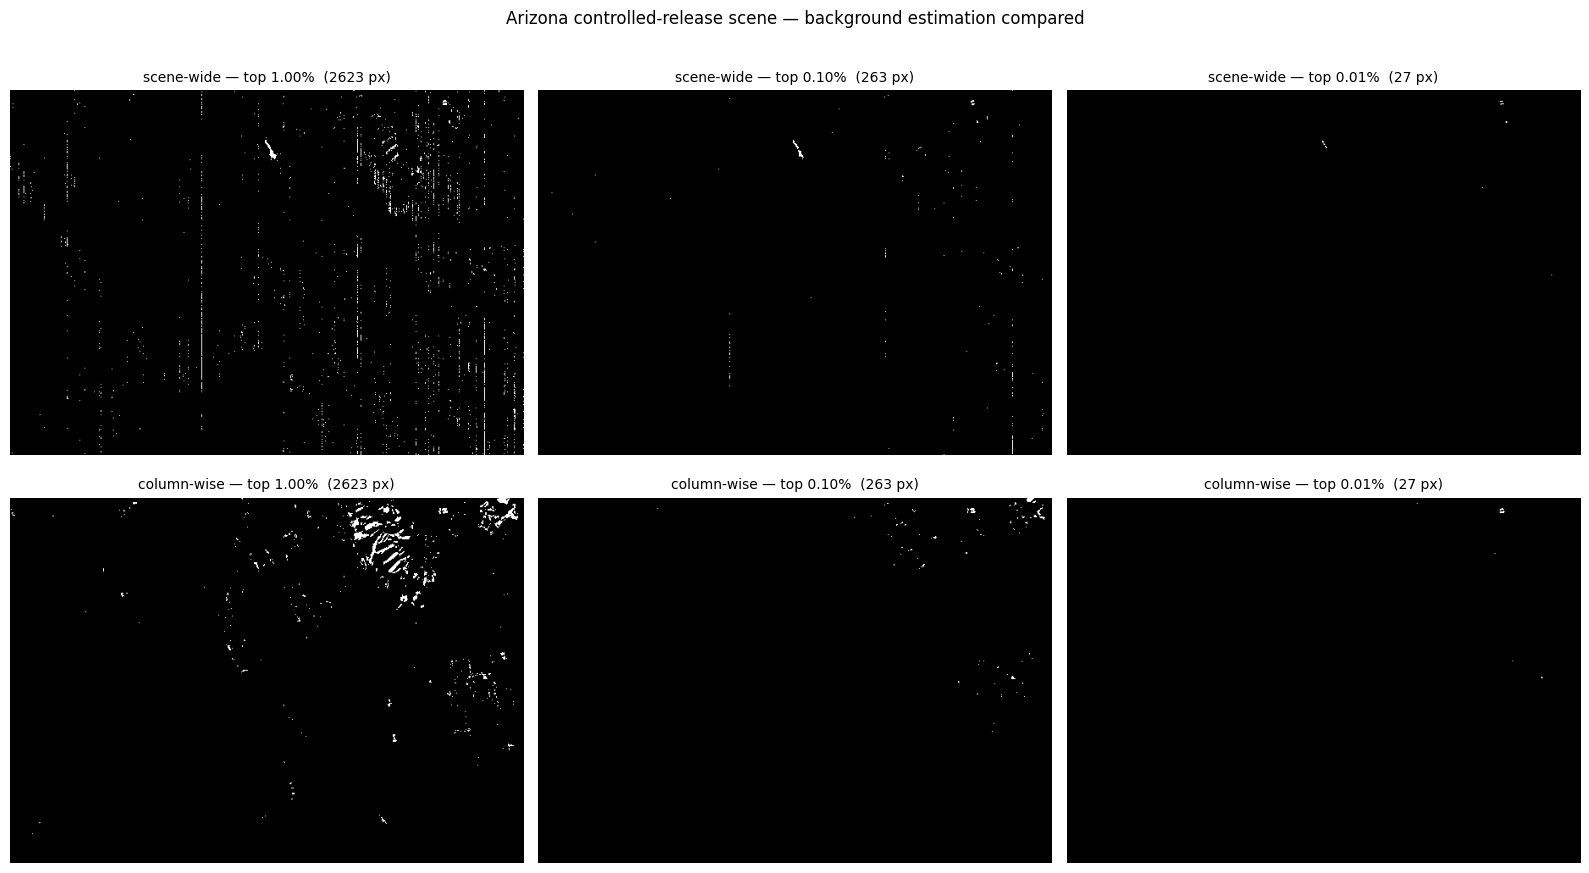

In [24]:
fig, ax = plt.subplots(2, 3, figsize=(16, 9))

for row, (m, lbl) in enumerate([(mf_scene, "scene-wide"), (mf_col, "column-wise")]):
    for col, pct in enumerate([99.0, 99.9, 99.99]):
        mask = m > np.nanpercentile(m, pct)
        ax[row, col].imshow(mask, cmap="gray")
        ax[row, col].set_title(f"{lbl} — top {100 - pct:.2f}%  ({int(mask.sum())} px)",
                               fontsize=10)
        ax[row, col].axis("off")

fig.suptitle("Arizona controlled-release scene — background estimation compared", y=1.00)
fig.tight_layout()
fig.savefig(FIGDIR / "az_scenewide_vs_columnwise.png", dpi=150, bbox_inches="tight")
plt.show()

**What confirms the fix:** vertical striping disappears from the bottom row while a
compact, elongated feature survives. If striping persists, the confound is not
column-wise gain and something else is going on.

## 6. Isolate the plume, then test its shape

The earlier shape test was partly circular: the filter selects pixels that look like
CH4, then the test asks whether those pixels look like CH4. Restricting to a single
spatially coherent component and comparing it against brightness-matched background
is the honest version — a mineral patch and a gas plume are selected the same way,
but only one of them has line structure at the right wavelengths.

In [25]:
TOP_PCT = 99.95   # tighten/loosen so the target component is a few tens of pixels

cand = mf_col > np.nanpercentile(mf_col, TOP_PCT)
lab, n = label(cand)
print(f"{n} connected components above the {TOP_PCT}th percentile\n")

rows = []
for cid in range(1, n + 1):
    comp = lab == cid
    npx  = int(comp.sum())
    if npx < 4:
        continue
    r, c = np.where(comp)
    h, w = np.ptp(r) + 1, np.ptp(c) + 1
    rows.append({
        "id": cid, "px": npx,
        "centroid": (int(r.mean()), int(c.mean())),
        "bbox_hw": (int(h), int(w)),
        "elongation": round(max(h, w) / max(1, min(h, w)), 2),
        "fill": round(npx / (h * w), 2),
        "mean_mf": round(float(np.nanmean(mf_col[comp])), 4),
    })

for r_ in sorted(rows, key=lambda d: -d["px"])[:12]:
    print(r_)

print("\nA wind-blown plume is elongated (>2) with moderate fill.")
print("A residual stripe is extremely elongated with fill near 1.0 and spans many rows.")

40 connected components above the 99.95th percentile

{'id': 1, 'px': 21, 'centroid': (3, 579), 'bbox_hw': (5, 6), 'elongation': np.float64(1.2), 'fill': np.float64(0.7), 'mean_mf': 1.1742}
{'id': 18, 'px': 13, 'centroid': (17, 513), 'bbox_hw': (3, 6), 'elongation': np.float64(2.0), 'fill': np.float64(0.72), 'mean_mf': 3.1748}
{'id': 12, 'px': 12, 'centroid': (14, 512), 'bbox_hw': (3, 6), 'elongation': np.float64(2.0), 'fill': np.float64(0.67), 'mean_mf': 3.07}
{'id': 16, 'px': 12, 'centroid': (17, 591), 'bbox_hw': (6, 4), 'elongation': np.float64(1.5), 'fill': np.float64(0.5), 'mean_mf': 1.181}
{'id': 21, 'px': 12, 'centroid': (24, 595), 'bbox_hw': (4, 6), 'elongation': np.float64(1.5), 'fill': np.float64(0.5), 'mean_mf': 1.1647}
{'id': 36, 'px': 9, 'centroid': (213, 560), 'bbox_hw': (3, 4), 'elongation': np.float64(1.33), 'fill': np.float64(0.75), 'mean_mf': 1.8122}
{'id': 19, 'px': 5, 'centroid': (22, 586), 'bbox_hw': (2, 4), 'elongation': np.float64(2.0), 'fill': np.float64(0.62), 

component 1: 21 px


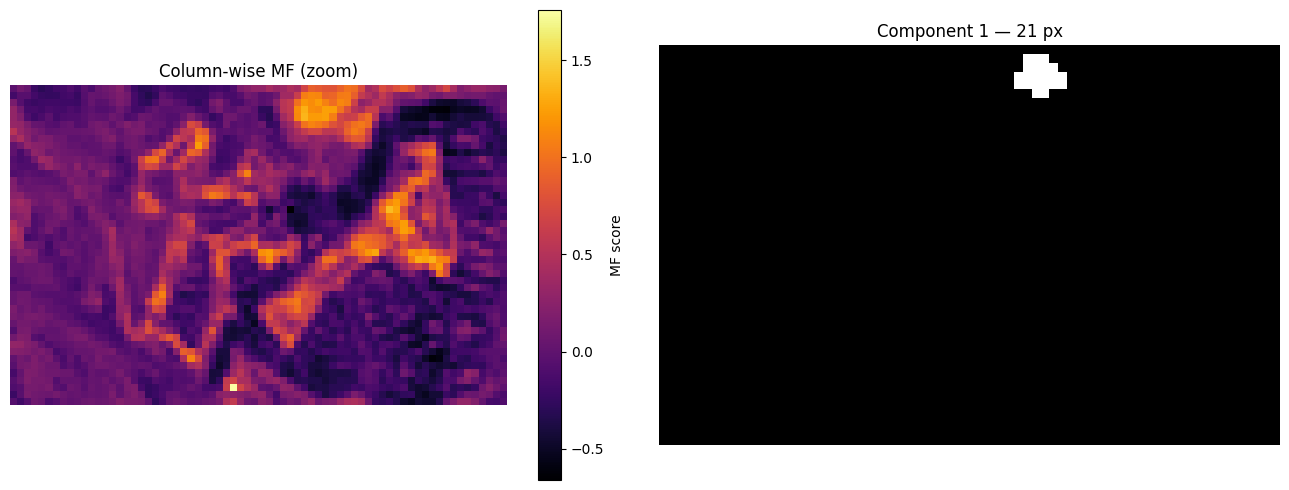

In [26]:
# Pick the component to test. Set by hand after reading the table above.
PLUME_ID = sorted(rows, key=lambda d: -d["px"])[0]["id"]   # default: largest

plume = (lab == PLUME_ID)
print(f"component {PLUME_ID}: {int(plume.sum())} px")

r, c = np.where(plume)
pad = 40
sub = (slice(max(0, r.min() - pad), r.max() + pad),
       slice(max(0, c.min() - pad), c.max() + pad))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im = ax[0].imshow(mf_col[sub], cmap="inferno")
plt.colorbar(im, ax=ax[0], label="MF score")
ax[0].set_title("Column-wise MF (zoom)")
ax[1].imshow(plume[sub], cmap="gray")
ax[1].set_title(f"Component {PLUME_ID} — {int(plume.sum())} px")
for a in ax:
    a.axis("off")
fig.tight_layout()
fig.savefig(FIGDIR / "az_plume_isolated.png", dpi=150, bbox_inches="tight")
plt.show()

outside CH4 bands : 0.957   (want ~1.00)
inside  CH4 bands : 0.881
differential      : 0.0751
HITRAN correlation: 0.455
observed peak     : 2206 nm
HITRAN peak       : 2370 nm
peak offset       : 164 nm   (want <15)


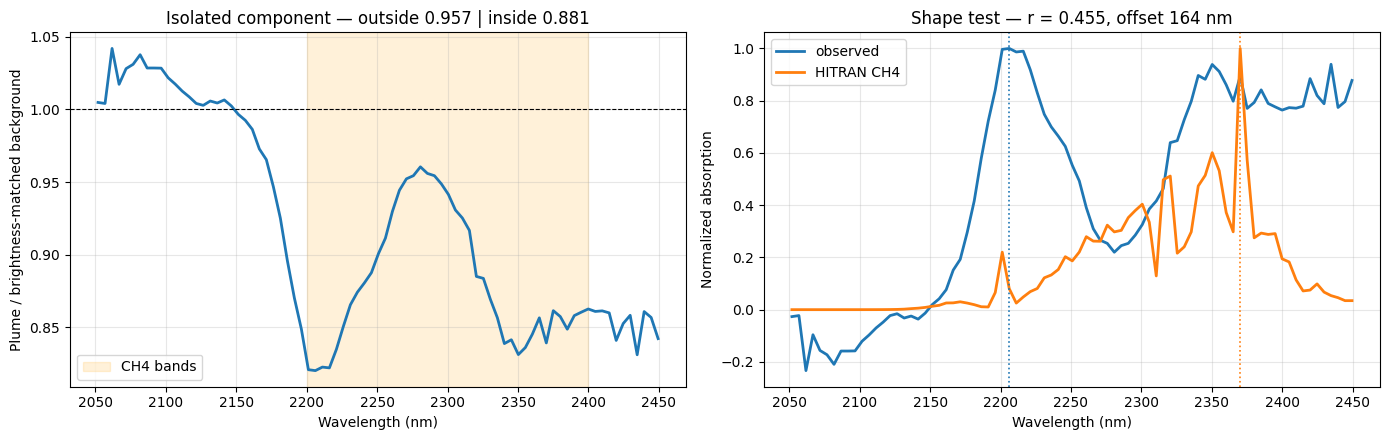

In [27]:
# Shape test on the isolated component alone
ratio_p, out_p, in_p = brightness_matched_ratio(
    X_az, valid_az, plume.ravel(), wl_swir_az
)

if ratio_p is None:
    print("Not enough pixels for a brightness-matched comparison.")
else:
    r_corr, obs_pk, ref_pk = hitran_shape_test(ratio_p, k_az, wl_swir_az)

    print(f"outside CH4 bands : {out_p:.3f}   (want ~1.00)")
    print(f"inside  CH4 bands : {in_p:.3f}")
    print(f"differential      : {out_p - in_p:.4f}")
    print(f"HITRAN correlation: {r_corr:.3f}")
    print(f"observed peak     : {obs_pk:.0f} nm")
    print(f"HITRAN peak       : {ref_pk:.0f} nm")
    print(f"peak offset       : {abs(obs_pk - ref_pk):.0f} nm   (want <15)")

    depth = 1.0 - ratio_p
    fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

    ax[0].plot(wl_swir_az, ratio_p, lw=2)
    ax[0].axhline(1.0, color="k", ls="--", lw=0.8)
    ax[0].axvspan(BAND_LO, BAND_HI, alpha=0.15, color="orange", label="CH4 bands")
    ax[0].set_xlabel("Wavelength (nm)")
    ax[0].set_ylabel("Plume / brightness-matched background")
    ax[0].set_title(f"Isolated component — outside {out_p:.3f} | inside {in_p:.3f}")
    ax[0].legend(); ax[0].grid(alpha=0.3)

    ax[1].plot(wl_swir_az, depth / np.nanmax(depth), lw=2, label="observed")
    ax[1].plot(wl_swir_az, k_az, lw=2, label="HITRAN CH4")
    ax[1].axvline(obs_pk, color="C0", ls=":", lw=1.2)
    ax[1].axvline(ref_pk, color="C1", ls=":", lw=1.2)
    ax[1].set_xlabel("Wavelength (nm)")
    ax[1].set_ylabel("Normalized absorption")
    ax[1].set_title(f"Shape test — r = {r_corr:.3f}, offset {abs(obs_pk - ref_pk):.0f} nm")
    ax[1].legend(); ax[1].grid(alpha=0.3)

    fig.tight_layout()
    fig.savefig(FIGDIR / "az_plume_shape_test.png", dpi=150, bbox_inches="tight")
    plt.show()

In [28]:
import requests

PLUME_NAME = "tan20241121t183727c00s4001-A"   # from the STAC metadata

r = requests.get(
    "https://api.carbonmapper.org/api/v1/catalog/plumes/annotated",
    params={"plume_names": PLUME_NAME, "sort": "desc", "limit": 10, "offset": 0},
    timeout=30,
)
print("status:", r.status_code)
r.raise_for_status()
js = r.json()
print("total_count:", js.get("total_count"))

for it in js.get("items", []):
    lon_p, lat_p = it["geometry_json"]["coordinates"]   # GeoJSON is [lon, lat]
    print(f"\nplume_id   : {it.get('plume_id')}")
    print(f"gas        : {it.get('gas')}")
    print(f"lat, lon   : {lat_p:.6f}, {lon_p:.6f}")
    for key in ("emission_auto", "emission_uncertainty_auto", "scene_timestamp",
                "instrument", "sector", "gas_qplume"):
        if key in it:
            print(f"{key:26s}: {it[key]}")

status: 200
total_count: 0


In [29]:
d = np.sqrt((lat_az - lat_p)**2 + (lon_az - lon_p)**2)
pr, pc = np.unravel_index(np.nanargmin(d), d.shape)
print(f"plume pixel: row {pr}, col {pc}")
print(f"MF score there      : {mf_col[pr, pc]:.3f}")
print(f"scene percentile    : {(mf_col < mf_col[pr, pc]).sum() / np.isfinite(mf_col).sum() * 100:.2f}")

NameError: name 'lat_p' is not defined

## Interpretation

| Outcome | Meaning | Next step |
|---|---|---|
| r > 0.8, offset < 15 nm, structure visible at 2310/2370 | Methane confirmed on a controlled release | Method validated — re-run the TX scene column-wise and trust the verdict |
| Broad bowl peaking near 2340, offset ~30 nm | Still a surface feature | The isolated component is not the release; try other components or a tighter percentile |
| outside far from 1.00 | Brightness matching failed | Too few background pixels at that brightness — widen k_neighbors |

The controlled release is the pivot. Until the pipeline finds a plume that is known
to be there, no negative result elsewhere carries weight.